In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# Electrical Routing — Deep Dive

This page covers electrical (metal-wire) routing in kfactory.
For a quick intro see [Routing Overview](overview.py).

Electrical routes are plain **Manhattan wires** — no bend cells, no radii.
The router places a filled rectangular path along the backbone and supports all the
same waypoint / stub / obstacle-avoidance features as optical routing.

| Topic | API |
|---|---|
| Basic wire bundle | `kf.routing.electrical.route_bundle(c, starts, ends, sep, place_layer=...)` |
| Per-route wire width | `route_bundle(..., route_width=...)` |
| Entry / exit stubs | `route_bundle(..., starts=..., ends=...)` |
| Waypoints | `route_bundle(..., waypoints=...)` |
| Obstacle avoidance | `route_bundle(..., bboxes=[...])` |
| Coplanar / dual-rail | `kf.routing.electrical.route_bundle_dual_rails(...)` |

## Setup

All coordinates in `KCell`-based APIs are in **DBU** (database units).
With the default `dbu = 0.001 µm/DBU`, 1 µm = 1 000 DBU.
Use `kf.kcl.to_dbu(x_µm)` to convert.

In [2]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    METAL1: kf.kdb.LayerInfo = kf.kdb.LayerInfo(11, 0)
    METAL2: kf.kdb.LayerInfo = kf.kdb.LayerInfo(12, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(99, 0)


L = LAYER()
kf.kcl.infos = L

# Typical metal wire: 2 µm wide, 2 µm separation between adjacent routes
WIRE_WIDTH = kf.kcl.to_dbu(2)  # 2_000 DBU
SEPARATION = kf.kcl.to_dbu(2)  # 2_000 DBU

## 1 · Basic wire bundle

`route_bundle` connects *N* start ports to *N* end ports with straight-corner wires.
Supply `place_layer` to draw all wires on a specific layer.

Port angles follow the KLayout integer convention:
`0` = East, `1` = North, `2` = West, `3` = South.
The most common pattern is start facing North (`angle=1`) and end facing South
(`angle=3`) with end ports above start ports, producing S-shaped wires.

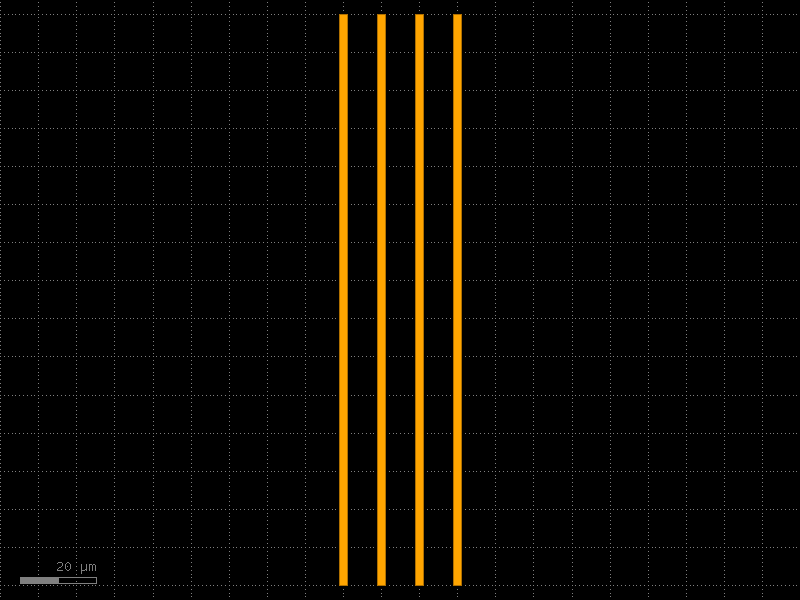

In [3]:
c_basic = kf.KCell("elec_basic_bundle")

n = 4
starts_basic = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 10), 0),
        width=WIRE_WIDTH,
        layer_info=L.METAL1,
    )
    for i in range(n)
]
ends_basic = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(i * 10), kf.kcl.to_dbu(150)),
        width=WIRE_WIDTH,
        layer_info=L.METAL1,
    )
    for i in range(n)
]

kf.routing.electrical.route_bundle(
    c_basic,
    starts_basic,
    ends_basic,
    separation=SEPARATION,
    place_layer=L.METAL1,
)
c_basic

## 2 · Overriding wire width with `route_width`

By default each route inherits the width of its start port.  Pass `route_width` (in
DBU) to draw all wires at a uniform width, or pass a list to set per-route widths.
This is useful when routing between ports of different widths or when the route must
be narrower than the pad.

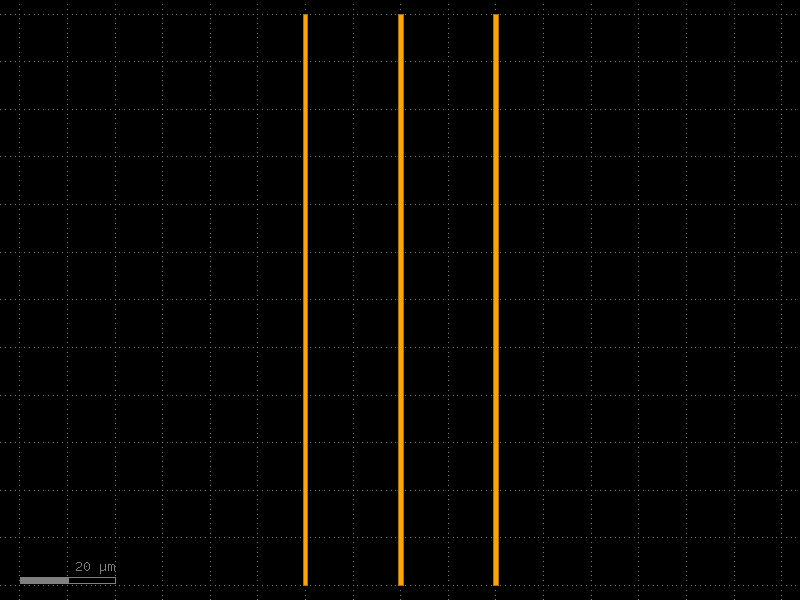

In [4]:
c_rw = kf.KCell("elec_route_width")

starts_rw = [
    kf.Port(
        name=f"pad_{i}",
        # Wide pads: 10 µm
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 20), 0),
        width=kf.kcl.to_dbu(10),
        layer_info=L.METAL1,
    )
    for i in range(3)
]
ends_rw = [
    kf.Port(
        name=f"wire_{i}",
        # Narrow landing pads: 2 µm
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(i * 20), kf.kcl.to_dbu(120)),
        width=WIRE_WIDTH,
        layer_info=L.METAL1,
    )
    for i in range(3)
]

# Route the wire at 1 µm regardless of the port widths.
kf.routing.electrical.route_bundle(
    c_rw,
    starts_rw,
    ends_rw,
    separation=SEPARATION,
    place_layer=L.METAL1,
    route_width=kf.kcl.to_dbu(1),
)
c_rw

## 3 · Entry and exit stubs — `starts` and `ends`

`starts` / `ends` force each route to travel straight for a given distance before the
router takes over.  A scalar applies the same stub to all routes; a list provides
per-route control (all values in DBU).

Stubs are useful for:
- maintaining clearance from a dense pad array before the wires fan out, or
- ensuring a minimum straight segment from a component port before turning.

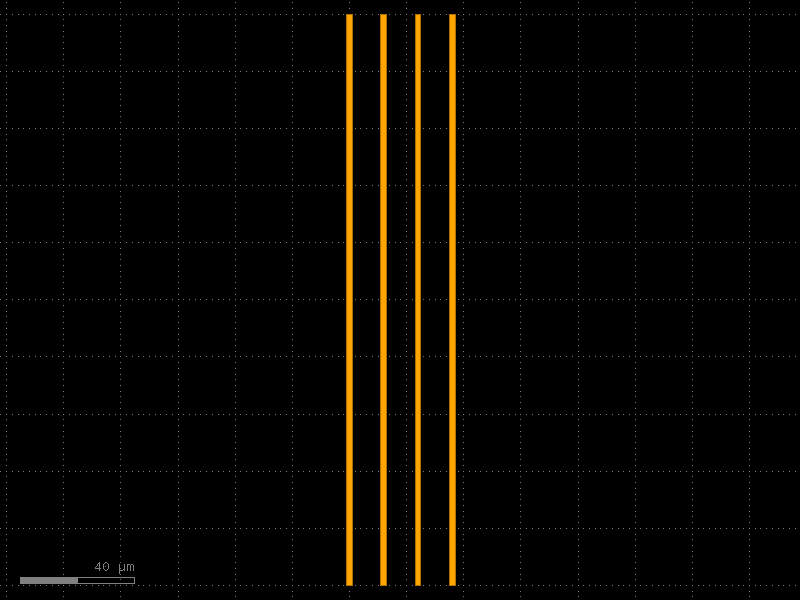

In [5]:
c_stubs = kf.KCell("elec_stubs")

starts_stub = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 12), 0),
        width=WIRE_WIDTH,
        layer_info=L.METAL1,
    )
    for i in range(4)
]
ends_stub = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(i * 12), kf.kcl.to_dbu(200)),
        width=WIRE_WIDTH,
        layer_info=L.METAL1,
    )
    for i in range(4)
]

kf.routing.electrical.route_bundle(
    c_stubs,
    starts_stub,
    ends_stub,
    separation=SEPARATION,
    place_layer=L.METAL1,
    starts=kf.kcl.to_dbu(20),  # 20 µm straight after each start port
    ends=kf.kcl.to_dbu(10),  # 10 µm straight before each end port
)
c_stubs

## 4 · Waypoints — routing through a fixed corridor

Waypoints force all routes to converge at a specific position and direction before
continuing to their end ports.

- Pass a `kdb.Trans` to specify a single convergence point with a direction (angle
  encoded as `0`=East, `1`=North, `2`=West, `3`=South).
- Pass a `list[kdb.Point]` to define a multi-point corridor (direction inferred from
  the first two points).

The example below routes 4 wires North from their start pads, forces them through a
narrow East-facing corridor in the middle of the layout, then continues up to the
end ports.

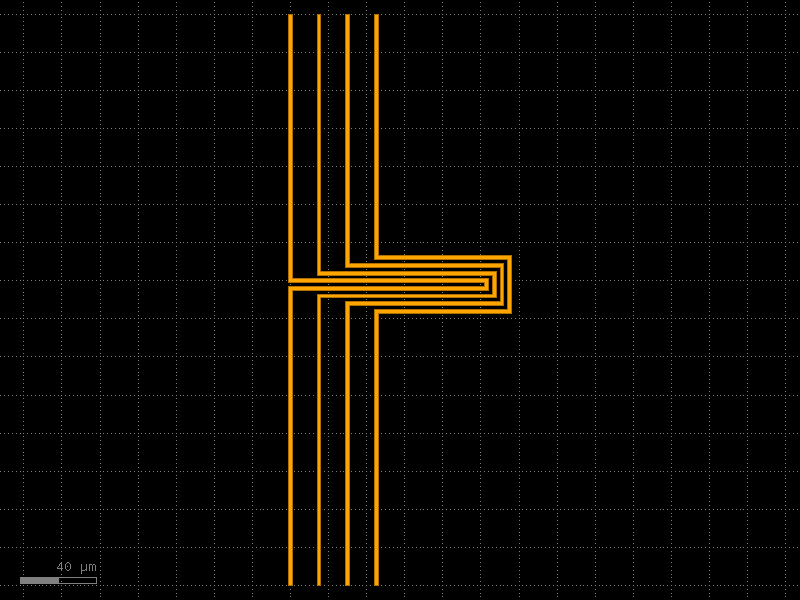

In [6]:
c_wp = kf.KCell("elec_waypoints")

starts_wp = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 15), 0),
        width=WIRE_WIDTH,
        layer_info=L.METAL1,
    )
    for i in range(4)
]
ends_wp = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(i * 15), kf.kcl.to_dbu(300)),
        width=WIRE_WIDTH,
        layer_info=L.METAL1,
    )
    for i in range(4)
]

# All 4 wires must pass through (x=100 µm, y=150 µm) heading East.
kf.routing.electrical.route_bundle(
    c_wp,
    starts_wp,
    ends_wp,
    separation=SEPARATION,
    place_layer=L.METAL1,
    waypoints=kf.kdb.Trans(0, False, kf.kcl.to_dbu(100), kf.kcl.to_dbu(150)),
)
c_wp

## 5 · Obstacle avoidance

Pass a list of `kdb.Box` objects as `bboxes` to mark keep-out regions.
The router automatically routes around them.

Obstacle boxes are in DBU and are defined as `kdb.Box(left, bottom, right, top)`.

> **Caveat**: the obstacle bbox must overlap (or touch) the bundle's own
> bounding box — an isolated box floating in empty space between the bundles
> is treated as if it weren't there.  Place the obstacle so it covers at
> least one of the start- or end-port regions.

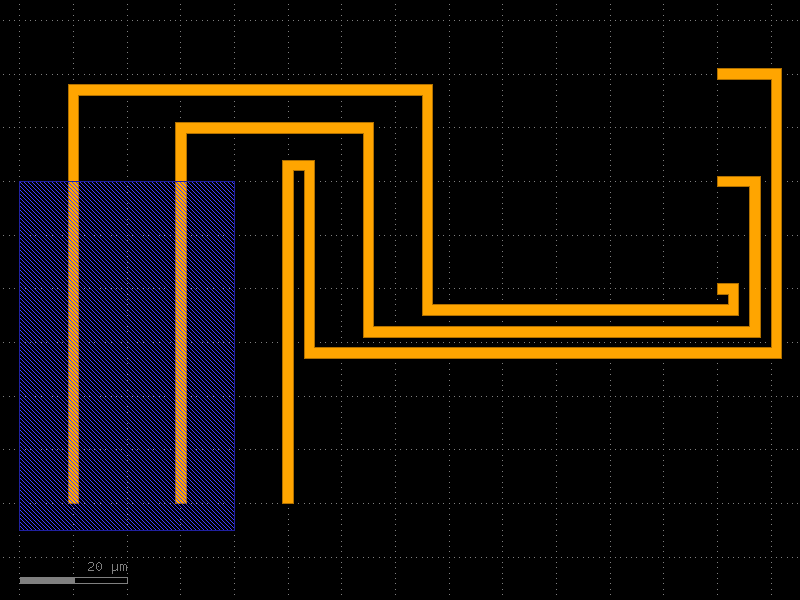

In [7]:
c_obs = kf.KCell("elec_obstacle")

# North-facing start ports at the bottom; East-facing end ports on the right.
# The bend the router must make to get from "north" to "east" gives the
# obstacle something meaningful to deflect.
starts_obs = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 20), 0),
        width=WIRE_WIDTH,
        layer_info=L.METAL1,
    )
    for i in range(3)
]
ends_obs = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(0, False, kf.kcl.to_dbu(120), kf.kcl.to_dbu(40 + i * 20)),
        width=WIRE_WIDTH,
        layer_info=L.METAL1,
    )
    for i in range(3)
]

# Keep-out box covering the left-most start port so the router must detour
# around it.  An obstacle floating in the middle (untouched by either port
# group) would not affect the route.
obstacle = kf.kdb.Box(
    kf.kcl.to_dbu(-10),
    kf.kcl.to_dbu(-5),
    kf.kcl.to_dbu(30),
    kf.kcl.to_dbu(60),
)
# Draw the obstacle on the floorplan layer for visibility.
c_obs.shapes(kf.kcl.find_layer(L.FLOORPLAN)).insert(obstacle)

kf.routing.electrical.route_bundle(
    c_obs,
    starts_obs,
    ends_obs,
    separation=SEPARATION,
    place_layer=L.METAL1,
    bboxes=[obstacle],
)
c_obs

## 6 · Dual-rail routing

`route_bundle_dual_rails` draws each wire as two parallel rails with a gap in between
— a common pattern for coplanar waveguide (CPW) transmission lines or differential
signal pairs.

Key parameters (all in DBU):

| Parameter | Meaning |
|---|---|
| `separation` | Minimum edge-to-edge spacing between adjacent *routes* |
| `width_rails` | Total outer width of the hollow path (rail + gap + rail) |
| `separation_rails` | Width of the inner gap cutout (must be < `width_rails`) |

For two 1 µm rails separated by a 2 µm gap, set
`width_rails = 4 µm` (total = rail + gap + rail) and `separation_rails = 2 µm`.

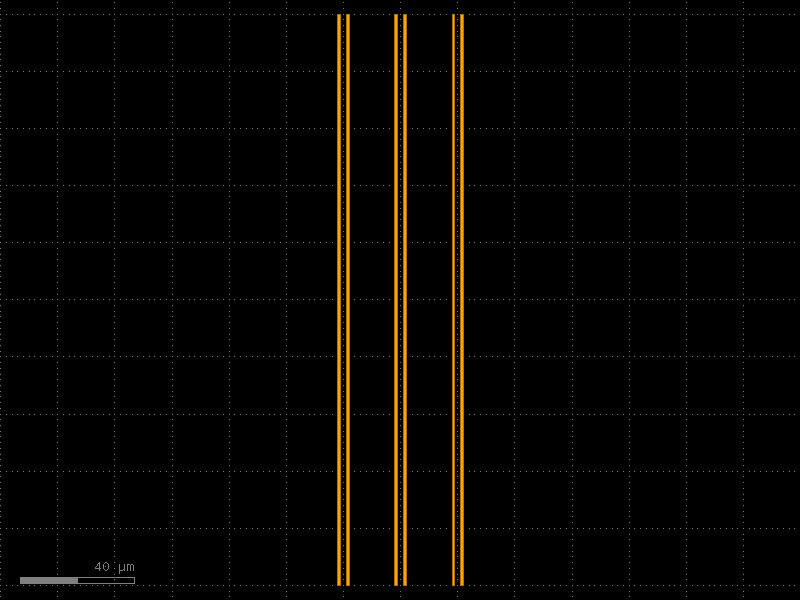

In [8]:
c_dr = kf.KCell("elec_dual_rails")

# Total outer width: rail(1µm) + gap(2µm) + rail(1µm) = 4µm
DR_TOTAL = kf.kcl.to_dbu(4)  # outer path width
DR_GAP = kf.kcl.to_dbu(2)  # inner hollow width (the gap between rails)

starts_dr = [
    kf.Port(
        name=f"in_{i}",
        trans=kf.kdb.Trans(1, False, kf.kcl.to_dbu(i * 20), 0),
        width=DR_TOTAL,
        layer_info=L.METAL1,
    )
    for i in range(3)
]
ends_dr = [
    kf.Port(
        name=f"out_{i}",
        trans=kf.kdb.Trans(3, False, kf.kcl.to_dbu(i * 20), kf.kcl.to_dbu(200)),
        width=DR_TOTAL,
        layer_info=L.METAL1,
    )
    for i in range(3)
]

kf.routing.electrical.route_bundle_dual_rails(
    c_dr,
    starts_dr,
    ends_dr,
    separation=kf.kcl.to_dbu(5),
    place_layer=L.METAL1,
    width_rails=DR_TOTAL,
    separation_rails=DR_GAP,
)
c_dr

## Summary

| Need | Parameter |
|---|---|
| Basic wire bundle | `route_bundle(c, starts, ends, sep, place_layer=L.METAL1)` |
| Uniform wire width | `route_width=kf.kcl.to_dbu(w_µm)` |
| Per-route widths | `route_width=[w1_dbu, w2_dbu, ...]` |
| Minimum straight before turn | `starts=dbu_length` (scalar or list) |
| Route through fixed corridor | `waypoints=kdb.Trans(angle, flip, x, y)` |
| Avoid keep-out regions | `bboxes=[kdb.Box(l, b, r, t)]` |
| Coplanar / differential pair | `route_bundle_dual_rails(..., width_rails=..., separation_rails=...)` |

All coordinates in `KCell`-based APIs are in **DBU** (1 nm = 1 DBU with default
`dbu=0.001`). Convert with `kf.kcl.to_dbu(x_µm)`.

## See Also

| Topic | Where |
|-------|-------|
| Routing overview (optical + electrical entry point) | [Routing: Overview](overview.py) |
| Bundle routing details: sort, sbend, bbox modes | [Routing: Bundle](bundle.py) |
| Optical waveguide routing | [Routing: Optical](optical.py) |
| Layer definitions and metal layers | [Core Concepts: Layers](../concepts/layers.py) |
| Cross-sections for wire geometry | [Cross-Sections](../components/cross_sections.py) |
| Port construction and connection | [Core Concepts: Ports](../concepts/ports.py) |